In [1]:
#'block_size': 256,
#'n_embed': 384,
#'n_layers': 6,
#'n_heads': 6,

# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: how does lpad work, does it?
# TODO: without residuals
# TODO: without layer norm
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 128,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 2,
    "learning_rate": 3e-4,
    "max_steps": 1000,
    #"dropout": 0.1,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
#DATASET_TEXT = DATASET_TEXT[:1000]

Find tokens:

In [4]:
chars = sorted(list(set(DATASET_TEXT)))
chars

['\n',
 ' ',
 '!',
 '$',
 '&',
 "'",
 ',',
 '-',
 '.',
 '3',
 ':',
 ';',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Create tokenizer:

In [5]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [6]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[-2.0438, -2.3093,  1.6266,  ...,  0.2334,  0.1478, -1.2930],
         [-2.0438, -2.3093,  1.6266,  ...,  0.2334,  0.1478, -1.2930],
         [-2.0438, -2.3093,  1.6266,  ...,  0.2334,  0.1478, -1.2930],
         ...,
         [ 1.3155,  0.0448,  0.6322,  ...,  1.0237, -0.4270,  1.1443],
         [ 1.3155,  0.0448,  0.6322,  ...,  1.0237, -0.4270,  1.1443],
         [ 1.3907, -1.0478,  1.0649,  ...,  1.3838, -0.1913, -0.9352]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [7]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[ 0.1592, -0.7260,  0.8274,  ...,  0.0894,  0.0982, -1.1239],
         [-1.9405,  0.1339,  0.5283,  ..., -0.7673, -0.1494, -0.5935],
         [-1.2403,  0.0784, -0.3053,  ...,  0.7834, -0.5977,  0.2866],
         ...,
         [-0.2108, -0.0399, -0.7530,  ..., -0.4732, -2.4773, -0.2046],
         [ 0.7986,  0.7425,  0.3017,  ..., -0.4032,  1.6212,  1.5172],
         [-2.2481,  0.1469, -1.8671,  ...,  0.9885,  0.0108,  0.8685]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [8]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[-1.8846e+00, -3.0353e+00,  2.4540e+00,  ...,  3.2278e-01,
           2.4600e-01, -2.4169e+00],
         [-3.9843e+00, -2.1755e+00,  2.1548e+00,  ..., -5.3391e-01,
          -1.5977e-03, -1.8865e+00],
         [-3.2841e+00, -2.2309e+00,  1.3213e+00,  ...,  1.0168e+00,
          -4.4996e-01, -1.0064e+00],
         ...,
         [ 1.1047e+00,  4.8747e-03, -1.2080e-01,  ...,  5.5053e-01,
          -2.9043e+00,  9.3978e-01],
         [ 2.1141e+00,  7.8728e-01,  9.3385e-01,  ...,  6.2057e-01,
           1.1942e+00,  2.6615e+00],
         [-8.5743e-01, -9.0095e-01, -8.0220e-01,  ...,  2.3722e+00,
          -1.8052e-01, -6.6739e-02]], grad_fn=<AddBackward0>))

Create batch sampler:

In [9]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[23, 10,  0,  ..., 57,  1, 43],
         [46, 43,  1,  ...,  1, 58, 46],
         [57, 58, 43,  ...,  1, 58, 46],
         ...,
         [ 1, 39,  1,  ..., 46, 39, 58],
         [ 1, 39, 50,  ...,  1, 21,  1],
         [53, 58,  6,  ..., 46, 53, 59]]),
 torch.Size([10, 128]),
 tensor([[10,  0, 27,  ...,  1, 43, 52],
         [43,  1, 47,  ..., 58, 46, 39],
         [58, 43, 56,  ..., 58, 46, 47],
         ...,
         [39,  1, 54,  ..., 39, 58,  1],
         [39, 50, 50,  ..., 21,  1, 61],
         [58,  6,  1,  ..., 53, 59,  1]]))

Test decoding batch:

In [10]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: K:
O cheerful colours! see where Oxford comes!

OXFORD:
Oxford, Oxford, for Lancaster!

GLOUCESTER:
The gates are open, let us e
y 0: :
O cheerful colours! see where Oxford comes!

OXFORD:
Oxford, Oxford, for Lancaster!

GLOUCESTER:
The gates are open, let us en

x 1: he injuries
That thou hast done me; therefore turn and draw.

ROMEO:
I do protest, I never injured thee,
But love thee better th
y 1: e injuries
That thou hast done me; therefore turn and draw.

ROMEO:
I do protest, I never injured thee,
But love thee better tha

x 2: ster service than to meddle with thy
mistress. Thou pratest, and pratest; serve with thy
trencher, hence!

AUFIDIUS:
Where is th
y 2: ter service than to meddle with thy
mistress. Thou pratest, and pratest; serve with thy
trencher, hence!

AUFIDIUS:
Where is thi

x 3: he prize; and he of both
That can assure my daughter greatest dower
Shall have my Bianca's love.
Say, Signior Gremio, What can y
y 3: e prize; and he of both
That can assure my daughter gr

In [11]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([128, 128, 64]),
 tensor([ 1.0665, -1.5865,  2.5223, -0.0727, -0.4907, -1.0320, -0.2007, -0.5742,
          0.1835,  1.6008,  0.6780, -2.0055,  0.6056,  0.1143, -0.7085, -3.2924,
         -1.0577, -0.7883, -1.1507,  0.0238,  1.2650,  2.0304,  0.4843,  0.9989,
          0.7991, -0.3914,  0.4503,  1.1896, -1.5029, -1.1553,  0.3784,  3.1560,
         -0.0479,  0.2486,  0.9444, -0.9664, -0.5507, -1.3249, -1.6947, -0.8918,
          0.9064,  0.6815,  2.3166, -0.9352,  1.8420,  0.7452,  0.6094,  0.2223,
         -0.5544, -2.5574,  2.5119, -0.1539,  1.3415,  0.3116,  0.5301, -0.6416,
         -0.2757, -0.1505, -0.3375, -0.1811, -0.3044,  1.4473,  0.8533, -2.8973],
        grad_fn=<SelectBackward0>))

In [12]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [13]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]))

In [14]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([128, 64, 128])

In [15]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([128, 128, 128]),
 tensor([-1799.3887,  1196.3108,   120.7146,  -103.0595, -2209.2539,   174.7531,
           176.2649,   606.2297,    44.4510,   120.1535,   690.5231,  1113.2841,
           386.1302,   424.0247,  -618.1760, -1235.1179,  1200.1482,  -308.5728,
          1585.8778,  -872.5539,  -246.1504,  -551.1561,    60.5422,  -320.1862,
           344.8694,  -583.5051,  1104.4081,  1082.3318, -1244.5875,  1263.6912,
          -310.8839,  -860.7772,  -717.3450,  -300.7463, -1998.9012,   846.6830,
           895.8005, -1046.0919,   280.6632,  1760.7156,  -175.8766,     8.8153,
          1286.0607,  1241.5007,  1116.4988,   423.6725,  1011.0723,  1137.4923,
          -853.5479,  1640.3552, -1332.2118,   676.8583,   437.2201,  1840.4911,
          1620.7772,   903.4421,   458.6491,  -322.4121,  1946.0353,    89.7233,
          -162.4670, -1118.5757,  -132.7380,   977.0690,   880.6249,   589.4625,
          1744.4170,  2303.2778,  1414.3832,   217.7424,   181.9710,  1811.1268

In [16]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([128, 128, 128]),
 tensor([-224.9236,  149.5388,   15.0893,  -12.8824, -276.1567,   21.8441,
           22.0331,   75.7787,    5.5564,   15.0192,   86.3154,  139.1605,
           48.2663,   53.0031,  -77.2720, -154.3897,  150.0185,  -38.5716,
          198.2347, -109.0692,  -30.7688,  -68.8945,    7.5678,  -40.0233,
           43.1087,  -72.9381,  138.0510,  135.2915, -155.5734,  157.9614,
          -38.8605, -107.5971,  -89.6681,  -37.5933, -249.8627,  105.8354,
          111.9751, -130.7615,   35.0829,  220.0894,  -21.9846,    1.1019,
          160.7576,  155.1876,  139.5623,   52.9591,  126.3840,  142.1865,
         -106.6935,  205.0444, -166.5265,   84.6073,   54.6525,  230.0614,
          202.5972,  112.9303,   57.3311,  -40.3015,  243.2544,   11.2154,
          -20.3084, -139.8220,  -16.5922,  122.1336,  110.0781,   73.6828,
          218.0521,  287.9097,  176.7979,   27.2178,   22.7464,  226.3909,
          107.4129, -129.4400,  -17.5784,  129.8276,  206.2932,   71.8

In [17]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [18]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [19]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([128, 128, 128]),
 tensor([[-224.9236,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  74.7831,   34.8502,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 128.8627,   -5.6873, -123.6088,  ...,      -inf,      -inf,
               -inf],
         ...,
         [-109.5905,   63.1840,   78.8789,  ..., -159.8179,      -inf,
               -inf],
         [ 226.3389,   -4.3113,  -28.0734,  ...,  -27.3782,   49.2829,
               -inf],
         [ -20.2835,  186.1608,   90.4960,  ...,  104.9745,  -12.4987,
          -110.2292]], grad_fn=<SelectBackward0>))

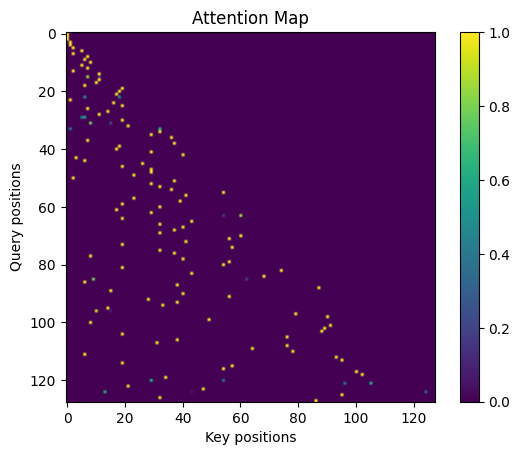

In [20]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [21]:
output = attention @ V
output.shape

torch.Size([128, 128, 64])

In [22]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([128, 128, 32]),
 tensor([[[ 2.6738, -1.3837, -1.6459,  ...,  3.3777, -0.8832,  2.1190],
          [ 2.6738, -1.3837, -1.6459,  ...,  3.3777, -0.8832,  2.1190],
          [ 2.6738, -1.3837, -1.6459,  ...,  3.3777, -0.8832,  2.1190],
          ...,
          [ 1.0311, -0.5323, -0.6174,  ...,  1.4126, -0.3598,  0.8047],
          [-0.2504, -2.3810, -0.3547,  ...,  1.7345,  0.1279,  0.2820],
          [ 1.6464, -1.3891, -0.6093,  ...,  1.9667, -1.6354,  2.3146]],
 
         [[ 1.6435, -0.0953,  0.6978,  ...,  2.4102, -0.9645,  1.9110],
          [ 1.6435, -0.0953,  0.6978,  ...,  2.4102, -0.9645,  1.9110],
          [ 2.5568, -0.4772,  1.9291,  ...,  1.7095, -2.8679,  0.1088],
          ...,
          [ 0.6744, -2.1384,  5.0078,  ...,  1.3338, -1.5208,  0.1183],
          [ 1.0310, -1.3230, -0.2670,  ...,  2.1979, -1.6260,  1.0067],
          [ 1.6434, -0.0953,  0.6977,  ...,  2.4097, -0.9645,  1.9109]],
 
         [[ 3.2584,  0.4565,  0.7309,  ...,  2.2431, -5.5353, -0.9437],

In [23]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        self.W_q = nn.Linear(embed_size, head_size)
        self.W_k = nn.Linear(embed_size, head_size)
        self.W_v = nn.Linear(embed_size, head_size)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[-0.8533,  0.0241,  0.6946],
          [-0.2767,  0.1685,  0.2722],
          [-0.2005,  0.2575,  0.0127],
          [-0.1858,  0.0358,  0.3252],
          [-0.1513,  0.1159,  0.1124],
          [-0.1357,  0.1689,  0.0615],
          [-0.1374,  0.1832,  0.0599],
          [-0.1405,  0.0350,  0.2730],
          [-0.0914,  0.1918,  0.2249],
          [-0.1564,  0.1951,  0.2046],
          [-0.1522,  0.2035,  0.1415],
          [-0.1674,  0.0639,  0.3326],
          [-0.1430,  0.1241,  0.1669],
          [-0.1875,  0.1702,  0.1885],
          [-0.2072,  0.1685,  0.1926],
          [-0.1888,  0.1738,  0.2622],
          [-0.1708,  0.1872,  0.1455],
          [-0.1466,  0.2393,  0.1113],
          [-0.1336,  0.2548,  0.1957],
          [-0.1587,  0.2277,  0.1297],
          [-0.1841,  0.2034,  0.1221],
          [-0.1824,  0.2009,  0.0824],
          [-0.1584,  0.1764,  0.0787],
          [-0.1567,  0.2226,  0.0616],
          [-0.1288,  0.1994,  0.0933],

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.0175,  0.1176,  0.0032,  ..., -0.0657, -0.1941,  0.0542],
          [-0.1009, -0.1621, -0.1726,  ...,  0.1004, -0.0791, -0.1517],
          [-0.3011,  0.0048, -0.2008,  ...,  0.0373,  0.0017,  0.0452],
          ...,
          [-0.1184,  0.0381, -0.2499,  ...,  0.0257,  0.0649,  0.0200],
          [-0.1197,  0.0391, -0.2360,  ..., -0.0343,  0.0719,  0.0562],
          [-0.0938,  0.0358, -0.2505,  ...,  0.0132,  0.0493,  0.0084]]],
        grad_fn=<ViewBackward0>))

In [25]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.0818,  0.0169,  0.0152,  ..., -0.0523, -0.0192,  0.0949],
          [ 0.0923,  0.0584, -0.0276,  ..., -0.0411, -0.0483,  0.0728],
          [ 0.0832,  0.0508, -0.0230,  ..., -0.0288, -0.0501,  0.0398],
          ...,
          [ 0.0576,  0.0072, -0.0678,  ..., -0.0362, -0.0609, -0.0016],
          [ 0.0603,  0.0134, -0.0663,  ..., -0.0310, -0.0574, -0.0135],
          [ 0.0571,  0.0145, -0.0761,  ..., -0.0339, -0.0521, -0.0045]]],
        grad_fn=<ViewBackward0>))

In [26]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = MultiHeadAttention()
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        x = x + self.head(self.ln1(x))    
        x = x + self.ffn(self.ln2(x))
        # TODO: what here?
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.4594, -1.5054, -2.1506,  ...,  0.6917,  0.9605,  0.4088],
          [ 0.6748, -0.6340,  0.7797,  ...,  1.2789, -1.1278,  1.1868],
          [-0.5333,  0.2639, -2.7041,  ...,  0.7762,  0.2530,  1.0749],
          ...,
          [ 1.5849,  0.3227,  1.4168,  ..., -1.0491,  1.1982, -0.8397],
          [ 0.9393, -0.6147,  0.8114,  ...,  0.9615, -1.1104,  0.5428],
          [-0.2627,  0.2345, -2.6532,  ...,  0.5693,  0.2102,  0.4048]]],
        grad_fn=<AddBackward0>))

In [27]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 46, 43, 50,
         50, 53]])

In [28]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 65]),
 tensor([-0.2974,  0.6483,  0.0307,  0.2137, -0.2501,  0.3401,  1.2589,  0.7780,
          0.3697,  0.1263,  0.0019,  0.0430,  0.6863, -0.2929,  0.4090, -0.5172,
         -0.1895,  1.1133,  0.6000,  0.4841,  0.1026,  0.2357,  0.1127, -0.9776,
          1.7728,  0.5690,  0.0413, -0.4074, -0.4790, -0.3151,  0.3462, -0.2109,
         -0.1144, -0.3542, -0.4826,  0.2430,  0.1528, -0.2001, -0.1885,  0.3763,
         -0.5652, -0.0030, -0.6723,  0.1468, -0.3785,  0.3258,  0.7036,  0.6996,
          0.6906,  0.8925,  0.3980, -0.8529, -0.1328,  0.1214, -0.3112, -0.5437,
          0.4813,  0.0294,  0.6920,  0.6560, -0.5080, -0.9373, -0.6700, -0.1810,
         -0.3694], grad_fn=<SelectBackward0>))

In [29]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:First Citi
y:irst Citiz


In [30]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:yourself:

y:ourself:
'
---
x:The patron
y:he patrone
---
x:s' sword;

y:' sword;
A
---
x:ry good
wh
y:y good
who
---
x:?

Provost
y:

Provost:
---
x:r duty and
y: duty and 
---
x:.

ROMEO:

y:

ROMEO:
G
---
x:nd men,
Sh
y:d men,
Sha
---
x:o less con
y: less conf
---
x: of histor
y:of history
---


In [31]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(65, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (head): MultiHeadAttention(
        (heads): ModuleList(
          (0-1): 2 x AttentionHead(
            (W_q): Linear(in_features=64, out_features=32, bias=True)
            (W_k): Linear(in_features=64, out_features=32, bias=True)
            (W_v): Linear(in_features=64, out_features=32, bias=True)
          )
        )
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=65, bias=True)
  (ln_final): LayerNorm((

In [33]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 1
losses = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")

Epoch 1/1: 100%|██████████| 8713/8713 [05:12<00:00, 27.86it/s, loss=1.6055]


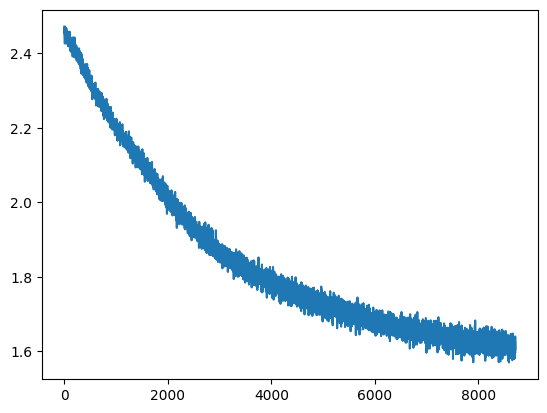

In [34]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()

In [35]:
model.eval()
print(model.generate("We are accounted poor citizens, the patricians good.", max_len=200))



POMPEY:
O, ame desplowern thought I must cadful young the goods some calue fool,
And that anch obercest this when our be holy hurde:
Who scallain! belth I liant; and is marcusener's last?

DEDWARS:

